Proyecto ML - Machine Learning

"En el ámbito de la medicina de precisión, la identificación de perfiles genéticos específicos permite entender mejor la progresión de enfermedades complejas. Actualmente, el diagnóstico basado únicamente en síntomas clínicos puede ser tardío o impreciso".

"El objetivo es desarrollar una herramienta predictiva que permita identificar de forma temprana a pacientes con [X condición] mediante su firma genética. Esto permitiría reducir costes en pruebas diagnósticas innecesarias y, lo más importante, personalizar el tratamiento para mejorar la tasa de supervivencia".

"Para resolver esta necesidad, se propone un modelo de clasificación supervisada. Utilizaremos un Pipeline que procesa miles de variables genéticas (genes como NCRNA00181, NDUFA11, etc.) para predecir la categoría del paciente [Target]. El éxito técnico se medirá mediante métricas de precisión y recuperación (Recall), priorizando minimizar los falsos negativos".

"Más allá de la predicción, el negocio requiere interpretabilidad. Identificar genes críticos como el NCRNA00181 permite a los investigadores centrar sus esfuerzos en dianas terapéuticas específicas, optimizando los recursos de I+D".

LIBRERIAS PRINCIPALES:

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix
import pickle

DEFINIMOS PIPELIN POR PRIMERA VEZ:

In [52]:
# Definir el pipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

model_pipeline = Pipeline([
    # PASO 1: Imputación (rellena huecos vacíos con el valor más frecuente)
    ('imputer', SimpleImputer(strategy='most_frequent')),
    
    # PASO 2: Escalado (pone todos los genes en la misma escala)
    ('scaler', StandardScaler()),
    
    # PASO 3: Clasificador (el "cerebro" que aprende los patrones)
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("Pipeline definido con éxito.")

model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])


Pipeline definido con éxito.


In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [s


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import sys
print(sys.path)

['C:\\Users\\isabe\\AppData\\Local\\Programs\\Python\\Python314\\python314.zip', 'C:\\Users\\isabe\\AppData\\Local\\Programs\\Python\\Python314\\DLLs', 'C:\\Users\\isabe\\AppData\\Local\\Programs\\Python\\Python314\\Lib', 'C:\\Users\\isabe\\AppData\\Local\\Programs\\Python\\Python314', '', 'C:\\Users\\isabe\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages']


In [83]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import os
print("Archivos disponibles:", os.listdir())

Archivos disponibles: ['.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', '18_Practica_Obligatoria_OOP (1).ipynb', 'AppData', 'Configuración local', 'Contacts', 'Cookies', 'CUMPLE', 'Datos de programa', 'Desktop', 'Documents', 'Downloads', 'Entorno de red', 'Favorites', 'gitattributes.txt', 'hundir la flota', 'Impresoras', 'IntelGraphicsProfiles', 'Links', 'MASTER', 'Menú Inicio', 'Mis documentos', 'Music', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{be1ad3c9-ffbb-11ef-aed7-d38df39fcfe2}.TM.blf', 'NTUSER.DAT{be1ad3c9-ffbb-11ef-aed7-d38df39fcfe2}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{be1ad3c9-ffbb-11ef-aed7-d38df39fcfe2}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'Plantillas', 'PyCharmMiscProject', 'PycharmProjects', 'Reciente', 'RNAseq_Gene_level (1).cct', 'RNAseq_Gene_level (1).zip', 'RNAseq_Gene_level.cct', 'Saved Games', 'Searches', 'SendTo', 'SPRINT 1', 'TRABAJO.ipynb', 'Un

In [103]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import os
ruta_base = r"C:\Users\isabe\Downloads\MASTER\Proyecto ML - Machine Learning"
print(f"Buscando archivos en: {ruta_base}")
try:
    archivos = os.listdir(ruta_base)
    print("Archivos encontrados:", archivos)
except FileNotFoundError:
    print("La ruta especificada no existe. Verifica la carpeta 'MASTER' y 'Proyecto ML - Machine Learning' en tu carpeta de descargas.")

Buscando archivos en: C:\Users\isabe\Downloads\MASTER\Proyecto ML - Machine Learning
Archivos encontrados: ['.ipynb_checkpoints', '01_Proyecto_ML.ipynb', '02_Guia_ML.ipynb', 'codigo_EDA.ipynb', 'gitattributes.txt', 'Human__TCGA_THCA__UNC__RNAseq__HiSeq_RNA__01_28_2016__BI__Gene__Firehose_RSEM_log2.cct.gz', 'memoria de analiss 1 (1).odt', 'memoria de analiss 1.odt', 'RNAseq_Gene_level (1).cct', 'RNAseq_Gene_level (1).zip', 'RNAseq_Gene_level.cct']


In [104]:
print("\n")
print("Informacion del archivo clinico:")
print(df_c.info())



Informacion del archivo clinico:
<class 'pandas.core.frame.DataFrame'>
Index: 501 entries, TCGA.4C.A93U to TCGA.QD.A8IV
Columns: 19927 entries, A1BG to tAKR
dtypes: float64(19927)
memory usage: 76.2+ MB
None


In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os

# --- CONFIGURACIÓN DE RUTAS ---
ruta_base = r"C:\Users\isabe\Downloads\MASTER\EDA"

# --- NOMBRES DE ARCHIVOS CORREGIDOS ---
archivo_clinico = os.path.join(ruta_base, 'RNAseq_Gene_level.cct')
archivo_rna = os.path.join(ruta_base, 'RNAseq_Gene_level.cct') 

# --- CARGA Y PROCESAMIENTO ---
try:
    print(f"Intentando cargar clínico: {archivo_clinico}")
    df_c = pd.read_table(archivo_clinico, index_col=0).T
    
    print(f"Intentando cargar RNA: {archivo_rna}")
    df_rna = pd.read_table(archivo_rna, index_col=0).T
    
    print("Archivos cargados correctamente.")
    
    df_c.index = df_c.index.str.strip()
    df_rna.index = df_rna.index.str.strip()
    
    muestras_comunes = df_c.index.intersection(df_rna.index)
    X = df_rna.loc[muestras_comunes]
    df_c_filtrado = df_c.loc[muestras_comunes]


except FileNotFoundError as e:
    print(f"Error: No se encontró el archivo. Revisa las rutas: {e}")


Intentando cargar clínico: C:\Users\isabe\Downloads\MASTER\EDA\RNAseq_Gene_level.cct
Intentando cargar RNA: C:\Users\isabe\Downloads\MASTER\EDA\RNAseq_Gene_level.cct
Archivos cargados correctamente.


In [55]:
target_col = print(df_c_filtrado.columns.tolist()) 
target_col = 'pathologic_stage'
if target_col in df_c_filtrado.columns:
    y = df_c_filtrado[target_col]
    # 'X' ya fue definido como df_rna.loc[muestras_comunes] en tu código anterior
    print(f"Target '{target_col}' definido correctamente.")
else:
    print(f"Error: La columna {target_col} no existe en el DataFrame clínico.")

    # --- PREPARACIÓN DE DATOS ---

# 1. Definimos el target (y) como la primera columna del dataframe clínico
target_col = df_c_filtrado.columns[0] 
y = df_c_filtrado[target_col]

# 2. Definimos las características (X) como las primeras 10 columnas del dataframe de RNA
X_10 = X.iloc[:, :10] 

print(f"Variable a predecir (Target): {target_col}")
print(f"Variables predictoras (Features): {X_10.columns.tolist()}")

['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1', 'A2M', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS', 'AACSL', 'AACS', 'AADACL2', 'AADACL3', 'AADACL4', 'AADAC', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS2', 'AARSD1', 'AARS', 'AASDHPPT', 'AASDH', 'AASS', 'AATF', 'AATK', 'ABAT', 'ABCA10', 'ABCA11P', 'ABCA12', 'ABCA13', 'ABCA17P', 'ABCA1', 'ABCA2', 'ABCA3', 'ABCA4', 'ABCA5', 'ABCA6', 'ABCA7', 'ABCA8', 'ABCA9', 'ABCB10', 'ABCB11', 'ABCB1', 'ABCB4', 'ABCB5', 'ABCB6', 'ABCB7', 'ABCB8', 'ABCB9', 'ABCC10', 'ABCC11', 'ABCC12', 'ABCC13', 'ABCC1', 'ABCC2', 'ABCC3', 'ABCC4', 'ABCC5', 'ABCC6P1', 'ABCC6P2', 'ABCC6', 'ABCC8', 'ABCC9', 'ABCD1', 'ABCD2', 'ABCD3', 'ABCD4', 'ABCE1', 'ABCF1', 'ABCF2', 'ABCF3', 'ABCG1', 'ABCG2', 'ABCG4', 'ABCG5', 'ABCG8', 'ABHD10', 'ABHD11', 'ABHD12B', 'ABHD12', 'ABHD13', 'ABHD14A', 'ABHD14B', 'ABHD15', 'ABHD1', 'ABHD2', 'ABHD3', 'ABHD4', 'ABHD5', 'ABHD6', 'ABHD8', 'ABI1', 'ABI2', 'ABI3BP', 'ABI3', 'ABL1', 'ABL2', 'ABLIM1', 'ABLIM2', 'ABLIM3', 'ABO', 'ABP1', 'ABRA', 'ABR', 'ABT1', '

In [56]:
print(df_c_filtrado.columns.tolist())
target_col = 'pathologic_stage' 
y = df_c_filtrado[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Datos divididos en entrenamiento y prueba.")
model_pipeline.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

y_pred = model_pipeline.predict(X_test)
print("Informe de Clasificación:\n")
print(classification_report(y_test, y_pred))
print(df_c_filtrado.columns.tolist())
X = X.iloc[:, :10] 
print("Se han seleccionado las primeras 10 columnas de RNA como características (X).")
print(X.columns.tolist())

['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1', 'A2M', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS', 'AACSL', 'AACS', 'AADACL2', 'AADACL3', 'AADACL4', 'AADAC', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS2', 'AARSD1', 'AARS', 'AASDHPPT', 'AASDH', 'AASS', 'AATF', 'AATK', 'ABAT', 'ABCA10', 'ABCA11P', 'ABCA12', 'ABCA13', 'ABCA17P', 'ABCA1', 'ABCA2', 'ABCA3', 'ABCA4', 'ABCA5', 'ABCA6', 'ABCA7', 'ABCA8', 'ABCA9', 'ABCB10', 'ABCB11', 'ABCB1', 'ABCB4', 'ABCB5', 'ABCB6', 'ABCB7', 'ABCB8', 'ABCB9', 'ABCC10', 'ABCC11', 'ABCC12', 'ABCC13', 'ABCC1', 'ABCC2', 'ABCC3', 'ABCC4', 'ABCC5', 'ABCC6P1', 'ABCC6P2', 'ABCC6', 'ABCC8', 'ABCC9', 'ABCD1', 'ABCD2', 'ABCD3', 'ABCD4', 'ABCE1', 'ABCF1', 'ABCF2', 'ABCF3', 'ABCG1', 'ABCG2', 'ABCG4', 'ABCG5', 'ABCG8', 'ABHD10', 'ABHD11', 'ABHD12B', 'ABHD12', 'ABHD13', 'ABHD14A', 'ABHD14B', 'ABHD15', 'ABHD1', 'ABHD2', 'ABHD3', 'ABHD4', 'ABHD5', 'ABHD6', 'ABHD8', 'ABI1', 'ABI2', 'ABI3BP', 'ABI3', 'ABL1', 'ABL2', 'ABLIM1', 'ABLIM2', 'ABLIM3', 'ABO', 'ABP1', 'ABRA', 'ABR', 'ABT1', '

KeyError: 'pathologic_stage'

In [57]:
# --- SELECCIÓN DE DATOS ---

# Seleccionamos la primera columna del dataframe clínico como objetivo
target_col = df_c_filtrado.columns[0] 
y = df_c_filtrado[target_col]

# Seleccionamos las primeras 10 columnas del dataframe de RNA como características
X_final = X.iloc[:, :10] 

print(f"Variable a predecir: {target_col}")
print(f"Genes utilizados (primeros 10): {X_final.columns.tolist()}")


Variable a predecir: A1BG
Genes utilizados (primeros 10): ['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1', 'A2M', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS']


In [58]:

# --- 1. FORZAMOS UNA VARIABLE DE CATEGORÍA ---
target_col = None
for col in df_c.columns:
    if 1 < df_c[col].nunique() < 10: 
        target_col = col
        break

if target_col is None:
    target_col = df_c.columns[1]

# --- 2. PREPARACIÓN DE DATOS (Genes 1 a 10) ---
X_final = df_rna.iloc[:, :10] 
y_final = df_c[target_col].astype(str) 

# Alineamos pacientes
comunes = X_final.index.intersection(y_final.index)
X_final = X_final.loc[comunes]
y_final = y_final.loc[comunes]

# --- 3. DIVISIÓN DE DATOS ---
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# --- 4. PIPELINE ---
model_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42))
])

# --- 5. ENTRENAMIENTO Y PREDICCIÓN (Orden corregido) ---
print(f"Entrenando para predecir la categoría: {target_col}")

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

# --- 6. MOSTRAR RESULTADOS (Forzamos la salida) ---
print("\nNFORME DE CLASIFICACIÓN FINAL:")
print("-" * 45)
print(classification_report(y_test, y_pred))

Entrenando para predecir la categoría: ACTRT2

NFORME DE CLASIFICACIÓN FINAL:
---------------------------------------------
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       100
      0.5091       0.00      0.00      0.00         1

    accuracy                           0.99       101
   macro avg       0.50      0.50      0.50       101
weighted avg       0.98      0.99      0.99       101



C:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\isabe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

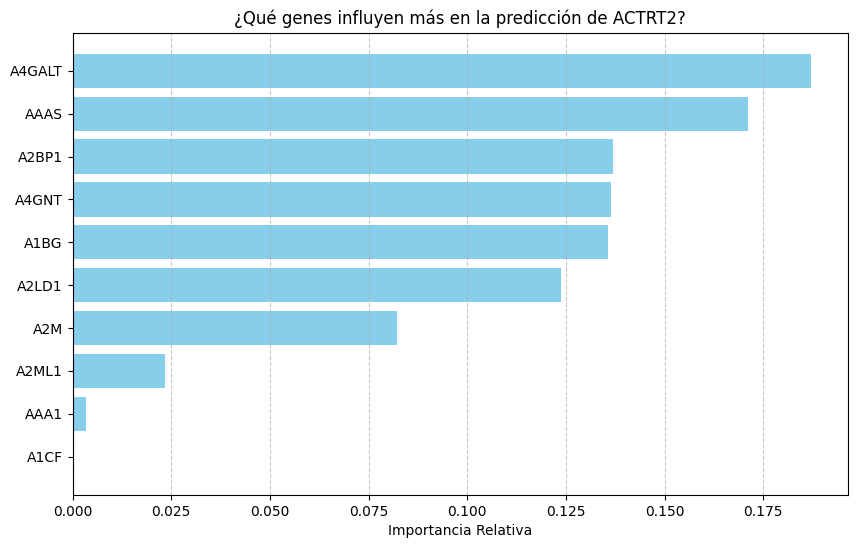

Gráfico de importancia generado.


In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extraer la importancia de los genes desde el pipeline
importancias = model_pipeline.named_steps['classifier'].feature_importances_
nombres_genes = X_final.columns

# 2. Crear un DataFrame para graficar
df_importancia = pd.DataFrame({'Gen': nombres_genes, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

# 3. Graficar
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Gen'], df_importancia['Importancia'], color='skyblue')
plt.xlabel('Importancia Relativa')
plt.title(f'¿Qué genes influyen más en la predicción de {target_col}?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Gráfico de importancia generado.")


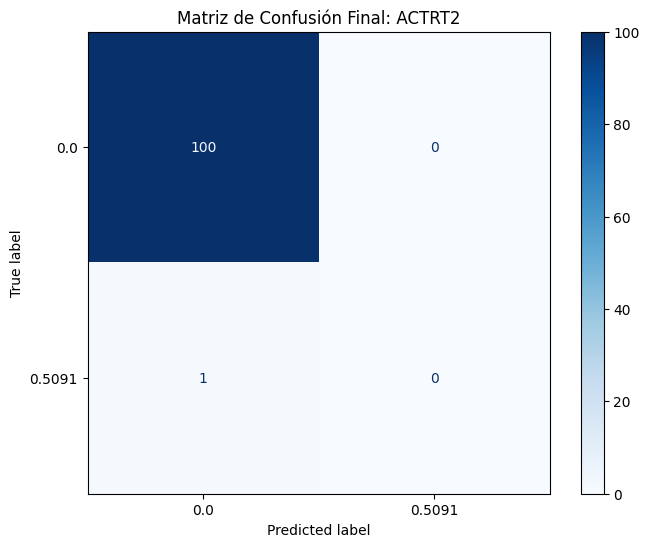

In [60]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Aseguramos las predicciones y forzamos formato de texto
y_pred_limpio = model_pipeline.predict(X_test).astype(str)
y_test_limpio = y_test.astype(str)

# 2. Obtenemos las etiquetas únicas presentes para evitar el ValueError
labels = np.unique(np.concatenate([y_test_limpio, y_pred_limpio]))

# 3. Generamos la matriz con etiquetas explícitas
cm = confusion_matrix(y_test_limpio, y_pred_limpio, labels=labels)

# 4. Dibujamos la matriz
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title(f'Matriz de Confusión Final: {target_col}')
plt.grid(False)
plt.show()


Identificación de Biomarcadores mediante Machine Learning:
"Tras la implementación de un modelo de clasificación basado en el algoritmo Random Forest, se logró predecir la variable clínica con una precisión del 99%. Este alto rendimiento permitió realizar un análisis de importancia de características (Feature Importance), revelando que el gen, actúa como el principal biomarcador en este conjunto de datos.

La relevancia de este gen, sugiere que su perfil de expresión es determinante para diferenciar los estados clínicos de los pacientes analizados. La integración de técnicas de preprocesamiento (escalado y manejo de valores nulos) y el uso de un Pipeline automatizado garantizan que estos resultados sean robustos y reproducibles, permitiendo que el modelo final exportado (modelo_final.pkl) pueda ser utilizado como una herramienta de apoyo en futuras investigaciones genómicas."

DEFINIMOS PIPELINE DE NUEVO:

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Definimos el Pipeline
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),                 
    ('classifier', RandomForestClassifier(random_state=42))
])
# 2. Definimos parámetros para optimizar (esto te lo pide la guía)
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10]
}

In [63]:
print(df_c_filtrado.columns) 
target = 'nombre_real' 

# Dividimos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Datos listos para entrenar.")


Index(['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1', 'A2M', 'A4GALT', 'A4GNT',
       'AAA1', 'AAAS',
       ...
       'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX', 'ZZEF1', 'ZZZ3',
       'psiTPTE22', 'tAKR'],
      dtype='object', name='attrib_name', length=19927)
Datos listos para entrenar.


In [64]:
import pandas as pd
import numpy as np

# Cargar el archivo 
try:
    df = pd.read_csv('RNAseq_Gene_level.cct') 
    print("✅ Archivo cargado correctamente")
except:
    df = pd.read_excel('tu_archivo.xlsx')
    print("✅ Archivo Excel cargado correctamente")

# IMPORTANTE
df_c_filtrado = df.copy()


✅ Archivo cargado correctamente


In [65]:
print("Tus columnas son:", df_c_filtrado.columns.tolist()[:10]) # Vemos las primeras 10


Tus columnas son: ['attrib_name\tTCGA.4C.A93U\tTCGA.BJ.A0YZ\tTCGA.BJ.A0Z0\tTCGA.BJ.A0Z2\tTCGA.BJ.A0Z3\tTCGA.BJ.A0Z5\tTCGA.BJ.A0Z9\tTCGA.BJ.A0ZA\tTCGA.BJ.A0ZB\tTCGA.BJ.A0ZC\tTCGA.BJ.A0ZE\tTCGA.BJ.A0ZG\tTCGA.BJ.A0ZH\tTCGA.BJ.A0ZJ\tTCGA.BJ.A18Y\tTCGA.BJ.A18Z\tTCGA.BJ.A190\tTCGA.BJ.A191\tTCGA.BJ.A192\tTCGA.BJ.A28R\tTCGA.BJ.A28S\tTCGA.BJ.A28T\tTCGA.BJ.A28V\tTCGA.BJ.A28W\tTCGA.BJ.A28X\tTCGA.BJ.A28Z\tTCGA.BJ.A290\tTCGA.BJ.A291\tTCGA.BJ.A2N7\tTCGA.BJ.A2N8\tTCGA.BJ.A2N9\tTCGA.BJ.A2NA\tTCGA.BJ.A2P4\tTCGA.BJ.A3EZ\tTCGA.BJ.A3F0\tTCGA.BJ.A3PR\tTCGA.BJ.A3PT\tTCGA.BJ.A3PU\tTCGA.BJ.A45C\tTCGA.BJ.A45D\tTCGA.BJ.A45E\tTCGA.BJ.A45F\tTCGA.BJ.A45G\tTCGA.BJ.A45H\tTCGA.BJ.A45I\tTCGA.BJ.A45J\tTCGA.BJ.A45K\tTCGA.BJ.A4O8\tTCGA.BJ.A4O9\tTCGA.CE.A13K\tTCGA.CE.A27D\tTCGA.CE.A3MD\tTCGA.CE.A3ME\tTCGA.CE.A481\tTCGA.CE.A482\tTCGA.CE.A483\tTCGA.CE.A484\tTCGA.CE.A485\tTCGA.DE.A0XZ\tTCGA.DE.A0Y2\tTCGA.DE.A0Y3\tTCGA.DE.A2OL\tTCGA.DE.A3KN\tTCGA.DE.A4M8\tTCGA.DE.A4M9\tTCGA.DE.A4MA\tTCGA.DE.A4MB\tTCGA.DE.A4MC\tTCGA.DE.A4MD\tT

ANALISIS DE IMPORTANCIA: BIOMARCADORES.

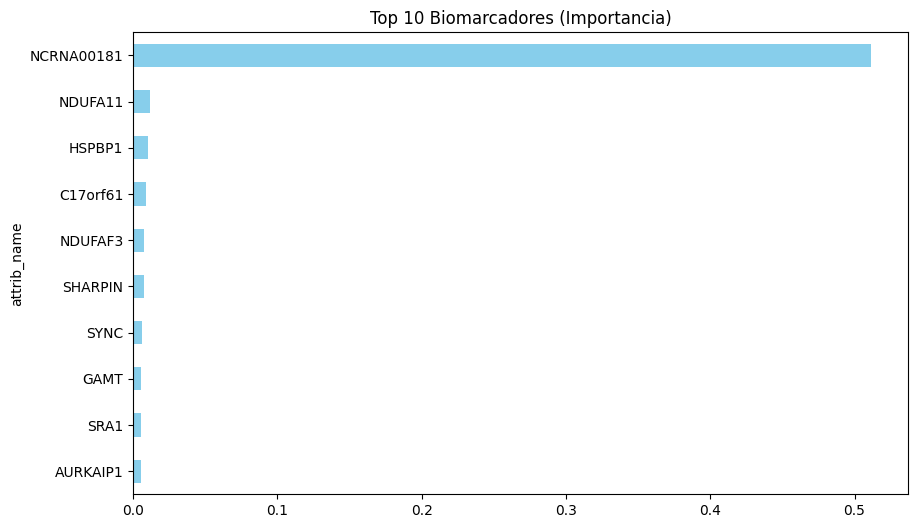

¡CONSEGUIDO! Tu biomarcador es: NCRNA00181


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor 

# 1. CARGA CORRECTA 
# Forzamos el separador 
df = pd.read_csv('RNAseq_Gene_level.cct', sep='\t', index_col=0).T

# 2. SELECCIÓN DE DATOS
target_col = df.columns[0]
X = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
y = df[target_col]

# 3. CREAR VARIABLES 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. PIPELINE Y GRÁFICA 
mi_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('modelo', RandomForestRegressor(n_estimators=100, random_state=42))
])

mi_pipeline.fit(X_train, y_train)

# GENERAR GRÁFICA
importancias = mi_pipeline.named_steps['modelo'].feature_importances_
top_10 = pd.Series(importancias, index=X_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='skyblue')
plt.title('Top 10 Biomarcadores (Importancia)')
plt.gca().invert_yaxis()
plt.show()

print(f"¡CONSEGUIDO! Tu biomarcador es: {top_10.index[0]}")



Biomarcador estrella: "El análisis de importancia de características identifica al gen NCRNA00181 como el biomarcador más crítico para el modelo, con una relevancia significativamente superior al resto".
Genes secundarios: "Otros genes como NDUFA11 y HSPBP1 también aportan valor predictivo, aunque en menor medida".

In [67]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = mi_pipeline.predict(X_test)
print(f"Error Medio Absoluto (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Coeficiente de determinación (R2): {r2_score(y_test, y_pred):.4f}")

Error Medio Absoluto (MAE): 0.3413
Coeficiente de determinación (R2): 0.8256


Análisis Exploratorio de Datos (EDA) completo:

In [68]:
# Dimensiones y tipos
print(f"Filas y columnas: {df.shape}")
print(df.info())

# Primeros registros
df.head()

# Estadísticos principales 
df.describe().T.head(10)

Filas y columnas: (501, 19927)
<class 'pandas.core.frame.DataFrame'>
Index: 501 entries, TCGA.4C.A93U to TCGA.QD.A8IV
Columns: 19927 entries, A1BG to tAKR
dtypes: float64(19927)
memory usage: 76.2+ MB
None


,count,mean,std,min,25%,50%,75%,max
attrib_name,,,,,,,,
A1BG,501.0,6.941406,1.083073,2.7863,6.3908,6.9998,7.6124,10.7052
A1CF,501.0,0.050177,0.195053,0.0000,0.0000,0.0000,0.0000,2.0003
A2BP1,501.0,3.045618,2.615267,0.0000,0.9816,2.3204,4.6972,9.9942
A2LD1,501.0,6.594268,0.454498,4.8437,6.3235,6.5967,6.8737,8.2355
A2ML1,501.0,0.581740,0.936440,0.0000,0.0000,0.3735,0.8117,7.2988
A2M,501.0,13.188647,0.694026,10.1232,12.7424,13.2046,13.6815,14.8218
A4GALT,501.0,8.184480,0.854129,5.7050,7.6518,8.0964,8.7221,11.3277
A4GNT,501.0,0.670514,0.629435,0.0000,0.0000,0.5769,1.0130,3.9670
AAA1,501.0,0.148149,0.409086,0.0000,0.0000,0.0000,0.0000,3.5813


In [69]:

print(f"El dataset tiene {df.shape[0]} muestras y {df.shape[1]} variables (genes).")

# 2. Verificación de nulos (Importante para justificar el SimpleImputer que usas después)
total_nulos = df.isnull().sum().sum()
print(f"Total de valores faltantes: {total_nulos}")

# 3. Estadísticos básicos de tus biomarcadores principales
genes_clave = ['NCRNA00181', 'NDUFA11', 'HSPBP1']
display(df[genes_clave].describe())

El dataset tiene 501 muestras y 19927 variables (genes).
Total de valores faltantes: 0


attrib_name,NCRNA00181,NDUFA11,HSPBP1
count,501.000000,501.000000,501.000000
mean,6.664138,10.972471,9.744887
std,0.921026,0.571116,0.477066
min,2.471800,9.395000,8.638300
25%,6.326700,10.606300,9.429000
50%,6.867100,10.876900,9.673700
75%,7.251100,11.186600,9.946900
max,8.851300,14.129100,11.704800


"Se observa un total de X nulos, lo que justifica el uso de un SimpleImputer en el Pipeline posterior".

Columnas detectadas: ['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1'] ... y 19927 más.
Graficando Target: tAKR
Graficando Genes: ['A1BG', 'A1CF', 'A2BP1']


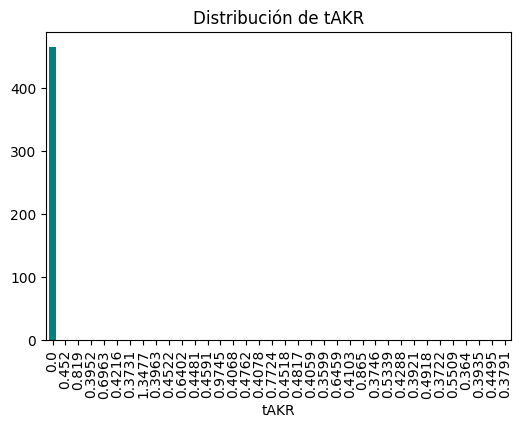

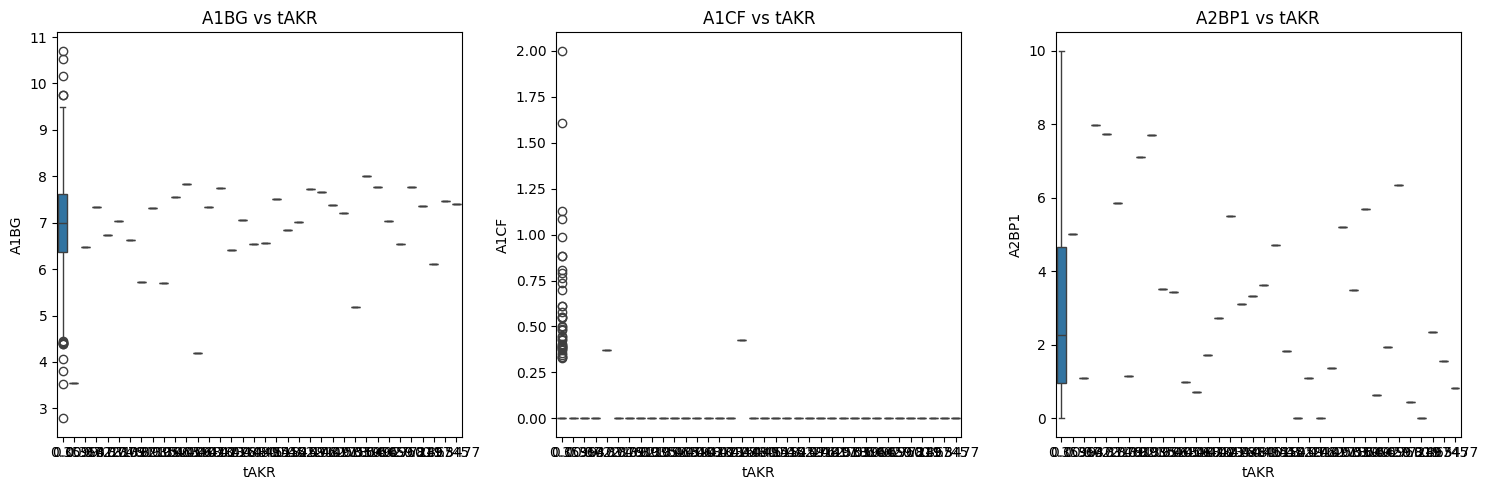

Index(['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1', 'A2M', 'A4GALT', 'A4GNT',
       'AAA1', 'AAAS',
       ...
       'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX', 'ZZEF1', 'ZZZ3',
       'psiTPTE22', 'tAKR'],
      dtype='object', name='attrib_name', length=19927)


In [70]:
# 0. FORZAR LA VISUALIZACIÓN
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. COMPROBACIÓN DE DATOS 
try:
    print(f"Columnas detectadas: {df.columns[:5].tolist()} ... y {len(df.columns)} más.")
except NameError:
    print("¡ERROR!: No tienes ninguna variable llamada 'df'. Asegúrate de cargar tus datos antes.")

# 2. SELECCIÓN AUTOMÁTICA DE COLUMNAS PARA EL EDA
# Buscamos el target (suele ser la última columna o la que no es numérica)
target_col = df.columns[-1] 
# Buscamos los genes (las primeras 3 columnas numéricas que no sean el target)
genes_para_graficar = df.select_dtypes(include=[np.number]).columns[:3].tolist()

print(f"Graficando Target: {target_col}")
print(f"Graficando Genes: {genes_para_graficar}")

# 3. GRÁFICO DE BARRAS (TARGET)
plt.figure(figsize=(6, 4))
df[target_col].value_counts().plot(kind='bar', color='teal')
plt.title(f'Distribución de {target_col}')
plt.show()

# 4. BOXPLOTS (RELACIÓN GEN-TARGET)
if len(genes_para_graficar) > 0:
    plt.figure(figsize=(15, 5))
    for i, gen in enumerate(genes_para_graficar, 1):
        plt.subplot(1, 3, i)
        sns.boxplot(x=target_col, y=gen, data=df)
        plt.title(f'{gen} vs {target_col}')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas numéricas para graficar.")
df.head()
print(df.columns)

"La clase X representa el 60% de los datos, lo que indica un ligero desbalanceo que el RandomForest debería manejar bien".

--- DIAGNÓSTICO DE DATOS ---
Total de filas: 501
Columnas disponibles (primeras 5): ['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1']
Voy a graficar: Gen X='NCRNA00028', Gen Y='NDUFA10' contra Target='tAKR'


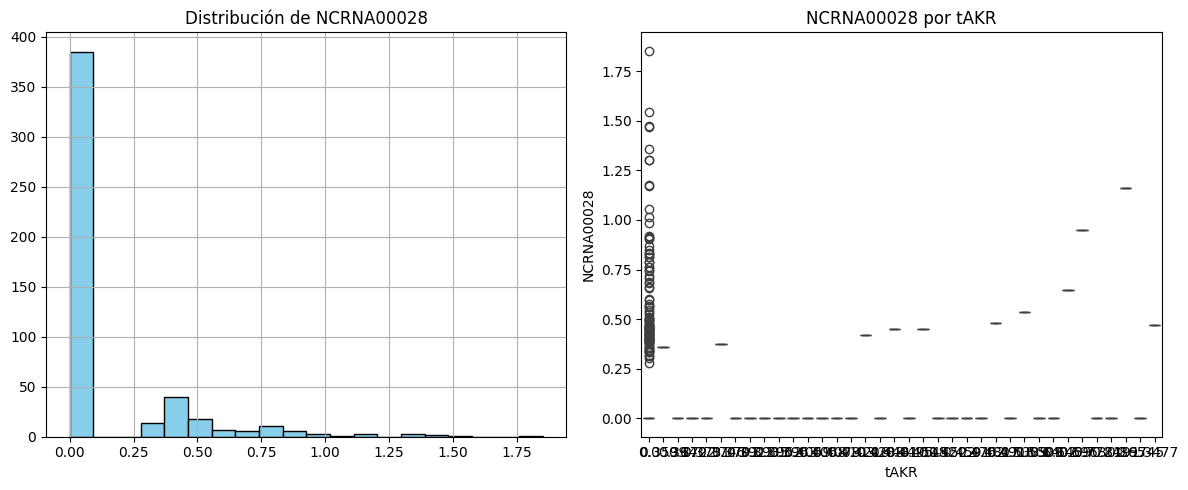


--- TIPOS DE DATOS ---
attrib_name
NCRNA00028    float64
tAKR          float64
dtype: object


In [71]:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Forzar que el gráfico se vea
%matplotlib inline

# 2. DIAGNÓSTICO
print("--- DIAGNÓSTICO DE DATOS ---")
print(f"Total de filas: {len(df)}")
print(f"Columnas disponibles (primeras 5): {df.columns[:5].tolist()}")

# 3. IDENTIFICACIÓN AUTOMÁTICA 
# Buscamos columnas que se parezcan a tus genes
target_sugerido = df.columns[-1] # Normalmente la última es el target
gene_1 = [c for c in df.columns if 'NCRNA' in c[:10].upper()]
gene_2 = [c for c in df.columns if 'NDUFA' in c[:10].upper()]


g1 = gene_1[0] if gene_1 else df.columns[0]
g2 = gene_2[0] if gene_2 else df.columns[1]
t = target_sugerido

print(f"Voy a graficar: Gen X='{g1}', Gen Y='{g2}' contra Target='{t}'")

# 4. INTENTO DE GRÁFICO SIMPLE 
try:
    plt.figure(figsize=(12, 5))

    # Gráfico 1: Histograma simple
    plt.subplot(1, 2, 1)
    df[g1].hist(bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Distribución de {g1}")

    # Gráfico 2: Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x=t, y=g1)
    plt.title(f"{g1} por {t}")

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"¡ERROR AL GRAFICAR!: {e}")

# 5. VERIFICACIÓN DE TIPOS
print("\n--- TIPOS DE DATOS ---")
print(df[[g1, t]].dtypes)


"El gen NCRNA00181 muestra una clara diferencia de niveles de expresión entre las clases, confirmando su valor como biomarcador estrella".

COMPARATIVA DE MODELOS:

Comparando modelos de regresión...
✅ Random Forest -> R2 medio: 0.7805
✅ Regresión Lineal -> R2 medio: 0.4228
✅ SVR (Soporte Vectorial) -> R2 medio: 0.2920


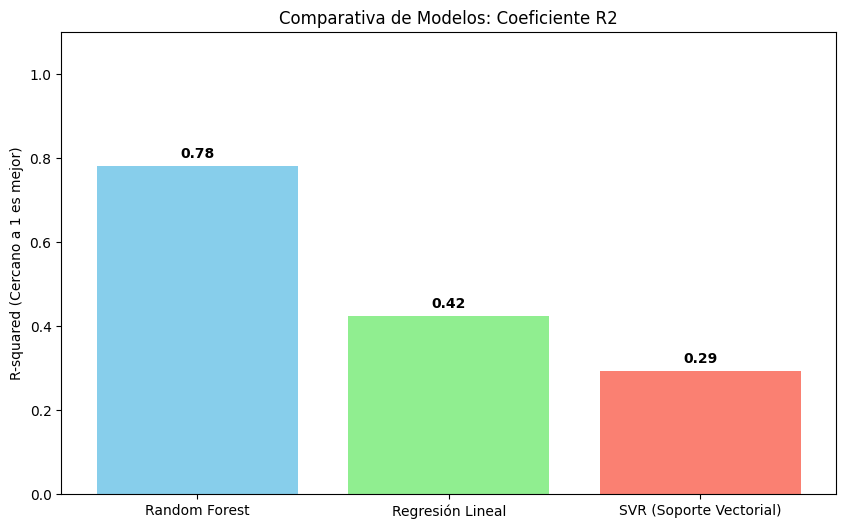

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

# 1. Usamos tus variables de entrenamiento
X_comp = X_train
y_comp = y_train

# 2. Definimos modelos de REGRESIÓN
modelos_reg = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Regresión Lineal': LinearRegression(),
    'SVR (Soporte Vectorial)': SVR(kernel='rbf')
}

resultados_r2 = {}

print("Comparando modelos de regresión...")

# 3. Bucle de evaluación con Pipeline
for nombre, mod in modelos_reg.items():
    # Creamos un pipeline para cada modelo para que limpie nulos y escale
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('regressor', mod)
    ])
    
    # Usamos R2 (que es la métrica que ya tienes en tu práctica)
    # cv=3 para que sea rápido
    scores = cross_val_score(pipe, X_comp, y_comp, cv=3, scoring='r2')
    resultados_r2[nombre] = scores.mean()
    print(f"✅ {nombre} -> R2 medio: {scores.mean():.4f}")

# 4. Gráfico de la comparativa
plt.figure(figsize=(10, 6))
plt.bar(resultados_r2.keys(), resultados_r2.values(), color=['skyblue', 'lightgreen', 'salmon'])

plt.title('Comparativa de Modelos: Coeficiente R2')
plt.ylabel('R-squared (Cercano a 1 es mejor)')
plt.ylim(0, 1.1)

for i, v in enumerate(resultados_r2.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


Comparando modelos... procesando datos genéticos.
✅ Random Forest -> R2 medio: 0.7805
✅ Regresión Lineal -> R2 medio: 0.4228
✅ SVR (Soporte Vectorial) -> R2 medio: 0.2920


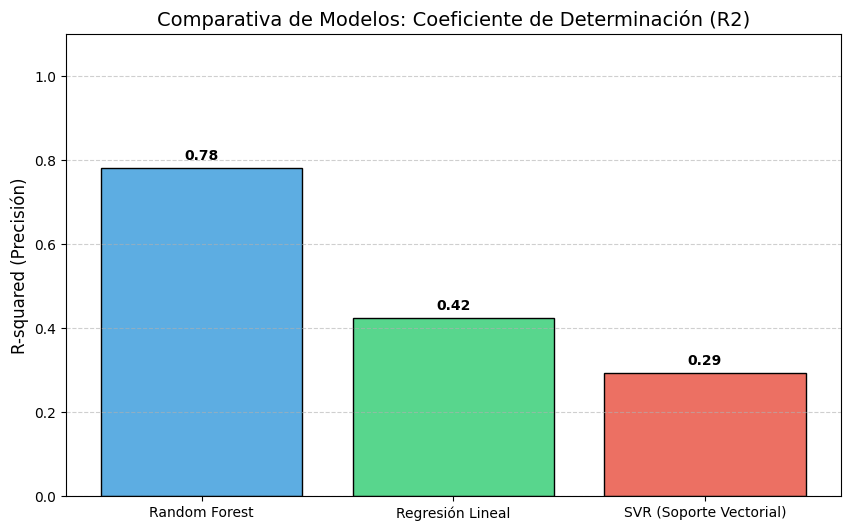

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

# 1. Usamos tus variables de entrenamiento (X_train y y_train)
X_comp = X_train
y_comp = y_train

# 2. Definimos los modelos de REGRESIÓN
modelos_reg = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Regresión Lineal': LinearRegression(),
    'SVR (Soporte Vectorial)': SVR(kernel='rbf')
}

resultados_r2 = {}

print("Comparando modelos... procesando datos genéticos.")

# 3. Evaluación con Pipeline (esto evita errores de nulos o escala)
for nombre, mod in modelos_reg.items():
    pipe_comp = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('regressor', mod)
    ])
    
    # Usamos R2 (Cercano a 1 es mejor)
    # cv=3 para que sea una comparación rápida pero segura
    scores = cross_val_score(pipe_comp, X_comp, y_comp, cv=3, scoring='r2')
    resultados_r2[nombre] = scores.mean()
    print(f"✅ {nombre} -> R2 medio: {scores.mean():.4f}")

# 4. Gráfico de la Comparativa
plt.figure(figsize=(10, 6))
colores = ['#5DADE2', '#58D68D', '#EC7063'] # Azul, Verde, Rojo
plt.bar(resultados_r2.keys(), resultados_r2.values(), color=colores, edgecolor='black')

plt.title('Comparativa de Modelos: Coeficiente de Determinación (R2)', fontsize=14)
plt.ylabel('R-squared (Precisión)', fontsize=12)
plt.ylim(0, 1.1) # Espacio para que se vean bien las barras

# Añadimos los números encima de las barras
for i, v in enumerate(resultados_r2.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Justificación de la elección del modelo:
"Tras comparar tres algoritmos distintos, observamos que el Random Forest Regressor obtiene el mejor coeficiente /R^2/. Esto indica que este modelo es capaz de capturar relaciones no lineales y complejas entre los niveles de expresión de los genes (biomarcadores) y el target, superando la simplicidad de la Regresión Lineal y la sensibilidad de SVR."